# Árboles para Series de Tiempo

En muchas ocasiones los árboles no son buenos manejando las tendencia, por eso se sugiere
quitar la tendencia y analizar la serie sin tendencia.

In [1]:
import pandas as pd
from pandas import read_csv
from matplotlib import pyplot
import numpy as np
import scipy as sp
import matplotlib.pylab as plt
import numpy as np
import sklearn

In [2]:
Pm25_DF = pd.read_csv("d-Shanghai-1317.txt",index_col=False,names=['PM25'])
Pm25_DF
Pm25_DF_sk=Pm25_DF
Pm25_DF.size

1611

In [3]:
indice = pd.date_range(start='1/1/2013', periods=1611, freq='D')
indice
PM25ts =pd.Series(Pm25_DF['PM25'].values,index=indice)
PM25df =pd.DataFrame(Pm25_DF['PM25'].values,index=indice)
type(PM25ts)

pandas.core.series.Series

2013-01-01    78.08333
2013-01-02    58.54167
2013-01-03    45.87500
2013-01-04    49.25000
2013-01-05    52.87500
Freq: D, dtype: float64


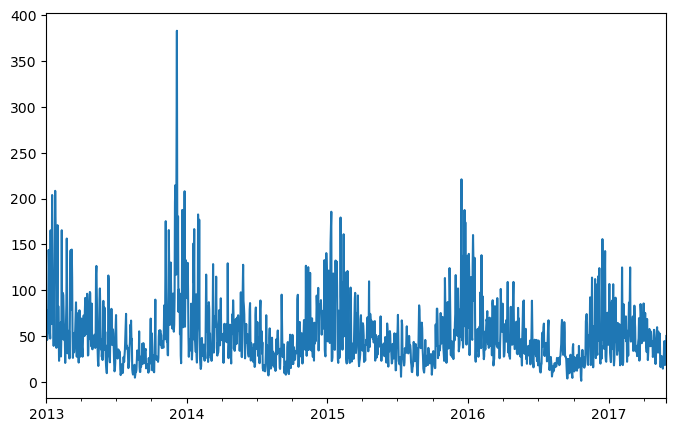

In [4]:
print(PM25ts.head(5))

PM25ts.plot(figsize=(8,5))
pyplot.show()

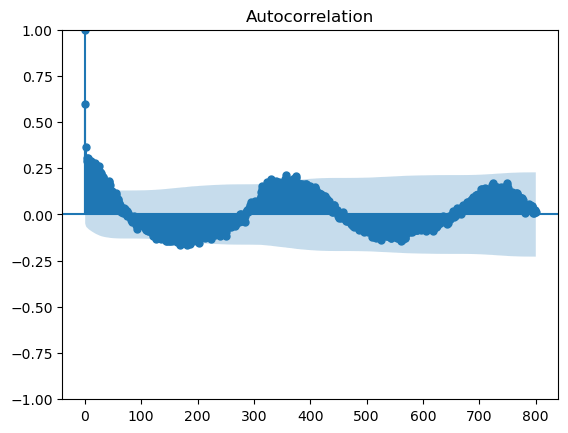

In [5]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(PM25ts,lags=800)
pyplot.show()

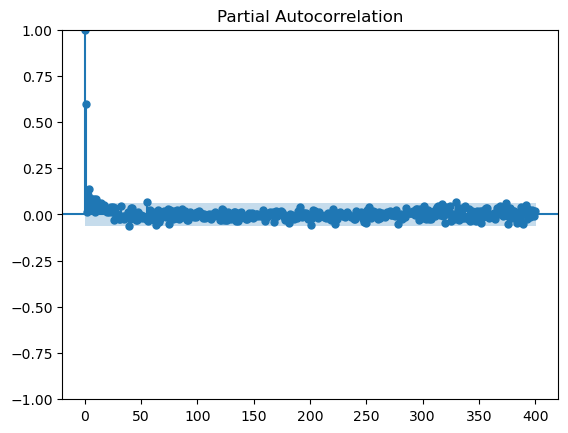

In [6]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(PM25ts,lags=400,method='ywm',alpha=0.01)
pyplot.show()

In [7]:
import statsmodels.api as sm
pacf =  sm.tsa.stattools.pacf(PM25ts, nlags=400,method='ywm')
T = len(PM25ts)

sig_test = lambda tau_h: np.abs(tau_h) > 2.58/np.sqrt(T)

In [8]:
pacf

array([ 1.00000000e+00,  5.97816671e-01,  1.30844662e-02,  1.04761299e-01,
        1.36687529e-01,  8.56474781e-02,  8.33878363e-02,  5.42210600e-02,
        8.10517485e-02,  1.35963250e-02,  8.59408315e-02,  6.55035506e-02,
        3.28306866e-02,  3.78878156e-02,  6.39845672e-02,  2.63762872e-02,
        3.78505465e-02,  4.97239184e-02,  4.08614491e-02,  1.87009571e-02,
        1.42161683e-02,  1.49318766e-02,  1.92964729e-02,  4.13788017e-02,
        1.17537368e-02,  4.22464072e-02, -3.03627302e-02,  3.70492475e-02,
       -8.20011151e-03,  4.05575929e-03, -2.64830378e-02, -2.38851883e-02,
        4.32149542e-02, -1.89858198e-02, -6.20374387e-03, -2.44593503e-02,
       -1.04578268e-02, -1.40599416e-02,  1.49030573e-02, -6.22563843e-02,
       -2.57600736e-02,  3.54343165e-02,  3.73289635e-02, -1.23728353e-02,
        8.35193424e-03, -3.23995498e-02, -2.86863308e-02,  1.48710640e-02,
       -1.01397298e-02, -1.55429186e-02, -3.46333779e-03, -1.85370774e-02,
       -8.19087460e-03, -

In [9]:
for i in range(len(pacf)):
    if sig_test(pacf[i]) == False:
        n_steps = i - 1
        print('n_steps set to', n_steps)
        break

n_steps set to 1


## Periodograma

4
0.002482929857231533


np.float64(402.75)

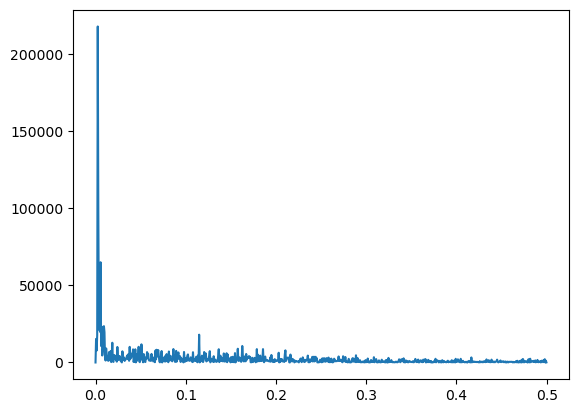

In [10]:

f, Pxx_den=sp.signal.periodogram(PM25ts.values)
plt.plot(f, Pxx_den)
#plt.axvline(x=1/50,color='red')
max_index_value = np.argmax(Pxx_den, axis=0)
print(max_index_value)
frecuencia_max=f[max_index_value]
print(frecuencia_max)
1/frecuencia_max

In [11]:
import heapq
print(heapq.nlargest(10, range(len(Pxx_den)), key=Pxx_den.__getitem__))


[4, 5, 9, 7, 15, 11, 6, 8, 16, 185]


In [12]:
print(1/f[4])
print(1/f[5])
print(1/f[9])
print(1/f[7])
print(1/f[15])
print(1/f[11])

402.75
322.2
179.0
230.14285714285717
107.39999999999999
146.45454545454547


1
0.00390625


np.float64(256.0)

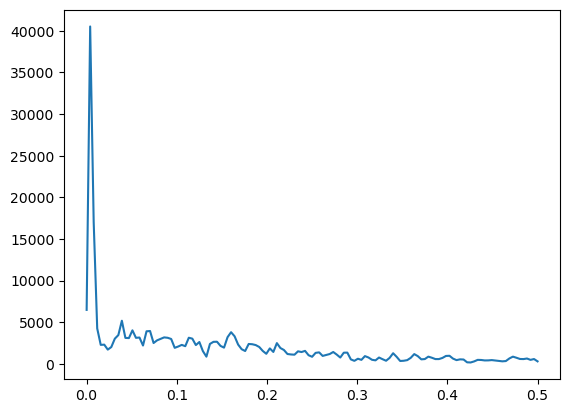

In [13]:
f_welch, Pxx_den_welch=sp.signal.welch(PM25ts.values)
plt.plot(f_welch, Pxx_den_welch)

max_index_value_welch = np.argmax(Pxx_den_welch, axis=0)
print(max_index_value_welch)
frecuencia_max_welch=f_welch[max_index_value_welch]
print(frecuencia_max_welch)
1/frecuencia_max_welch






In [14]:
import heapq
print(heapq.nlargest(10, range(len(Pxx_den_welch)), key=Pxx_den_welch.__getitem__))
print(1/f_welch[1])
print(1/f_welch[2])
print(1/f_welch[3])


[1, 2, 0, 10, 3, 13, 18, 17, 41, 9]
256.0
128.0
85.33333333333333


## Creación de variables rezagadas

In [15]:
print(PM25df[0:372])
print(len(PM25df[0:370]))

                    0
2013-01-01   78.08333
2013-01-02   58.54167
2013-01-03   45.87500
2013-01-04   49.25000
2013-01-05   52.87500
...               ...
2014-01-03  129.91670
2014-01-04   99.75000
2014-01-05   50.33333
2014-01-06   27.54167
2014-01-07   46.20833

[372 rows x 1 columns]
370


In [16]:
from pandas import DataFrame
# reframe as supervised learning
# lag observation (t-1) is the input variable and t is the output variable.
df1 = DataFrame()
print(df1)

Empty DataFrame
Columns: []
Index: []


In [17]:

for i in range(1,11,1):
    df1[['t-'+str(i)]] = PM25df.shift(i)
    
for i in range(364,371,1):   
    df1[['t-'+str(i)]] = PM25df.shift(i)
print(df1)

                 t-1       t-2       t-3       t-4       t-5       t-6  \
2013-01-01       NaN       NaN       NaN       NaN       NaN       NaN   
2013-01-02  78.08333       NaN       NaN       NaN       NaN       NaN   
2013-01-03  58.54167  78.08333       NaN       NaN       NaN       NaN   
2013-01-04  45.87500  58.54167  78.08333       NaN       NaN       NaN   
2013-01-05  49.25000  45.87500  58.54167  78.08333       NaN       NaN   
...              ...       ...       ...       ...       ...       ...   
2017-05-26  44.62500  39.87500  18.33333  23.29167  14.62500  18.20833   
2017-05-27  25.83333  44.62500  39.87500  18.33333  23.29167  14.62500   
2017-05-28  29.12500  25.83333  44.62500  39.87500  18.33333  23.29167   
2017-05-29  18.75000  29.12500  25.83333  44.62500  39.87500  18.33333   
2017-05-30  22.87500  18.75000  29.12500  25.83333  44.62500  39.87500   

                 t-7       t-8       t-9      t-10     t-364     t-365  \
2013-01-01       NaN       NaN       

In [18]:
# Create column t
df1['t'] = PM25df.values
print(df1.head(371))

                  t-1        t-2        t-3        t-4        t-5        t-6  \
2013-01-01        NaN        NaN        NaN        NaN        NaN        NaN   
2013-01-02   78.08333        NaN        NaN        NaN        NaN        NaN   
2013-01-03   58.54167   78.08333        NaN        NaN        NaN        NaN   
2013-01-04   45.87500   58.54167   78.08333        NaN        NaN        NaN   
2013-01-05   49.25000   45.87500   58.54167   78.08333        NaN        NaN   
...               ...        ...        ...        ...        ...        ...   
2014-01-02  126.70830   96.45833  114.79170  132.87500   98.87500   60.29167   
2014-01-03   91.45833  126.70830   96.45833  114.79170  132.87500   98.87500   
2014-01-04  129.91670   91.45833  126.70830   96.45833  114.79170  132.87500   
2014-01-05   99.75000  129.91670   91.45833  126.70830   96.45833  114.79170   
2014-01-06   50.33333   99.75000  129.91670   91.45833  126.70830   96.45833   

                  t-7        t-8       

In [19]:
# Create a new subsetted dataframe, removing Nans from first 370 rows
df1_PM25 = df1[370:]
print(df1_PM25)
df1_PM25.size

                 t-1       t-2        t-3        t-4        t-5        t-6  \
2014-01-06  50.33333  99.75000  129.91670   91.45833  126.70830   96.45833   
2014-01-07  27.54167  50.33333   99.75000  129.91670   91.45833  126.70830   
2014-01-08  46.20833  27.54167   50.33333   99.75000  129.91670   91.45833   
2014-01-09  38.91667  46.20833   27.54167   50.33333   99.75000  129.91670   
2014-01-10  34.29167  38.91667   46.20833   27.54167   50.33333   99.75000   
...              ...       ...        ...        ...        ...        ...   
2017-05-26  44.62500  39.87500   18.33333   23.29167   14.62500   18.20833   
2017-05-27  25.83333  44.62500   39.87500   18.33333   23.29167   14.62500   
2017-05-28  29.12500  25.83333   44.62500   39.87500   18.33333   23.29167   
2017-05-29  18.75000  29.12500   25.83333   44.62500   39.87500   18.33333   
2017-05-30  22.87500  18.75000   29.12500   25.83333   44.62500   39.87500   

                  t-7        t-8        t-9       t-10      t-3

22338

skforecast  es una librería de python que permite "
Time series forecasting with scikit-learn regressors", la cual permiten desde la partición de los datos, y la cración del aprendizaje supervisado.Funciona bien con las funciones de sklearn. Ver https://joaquinamatrodrigo.github.io/skforecast/0.5.0/index.html.

# Dividir los datos


In [20]:
# Split data

PM25split = df1_PM25.values
# split into lagged variables and original time series
X1= PM25split[:, 0:-1]  # slice all rows and start with column 0 and go up to but not including the last column
y1 =PM25split[:,-1]  # slice all rows and last column, essentially separating out 't' column

In [21]:
print(X1)
print(y1)

[[ 50.33333  99.75    129.9167  ...  45.875    58.54167  78.08333]
 [ 27.54167  50.33333  99.75    ...  49.25     45.875    58.54167]
 [ 46.20833  27.54167  50.33333 ...  52.875    49.25     45.875  ]
 ...
 [ 29.125    25.83333  44.625   ...  88.91667  69.41667  87.75   ]
 [ 18.75     29.125    25.83333 ...  31.91667  88.91667  69.41667]
 [ 22.875    18.75     29.125   ...  30.66667  31.91667  88.91667]]
[27.54167 46.20833 38.91667 ... 18.75    22.875   50.20833]


In [22]:
print(X1[0])
print(y1[0])

[ 50.33333  99.75    129.9167   91.45833 126.7083   96.45833 114.7917
 132.875    98.875    60.29167 144.       85.125    52.875    49.25
  45.875    58.54167  78.08333]
27.54167


In [23]:


Y1 = y1
print('Complete Observations for Target after Supervised configuration: %d' %len(Y1))
traintarget_size = int(len(Y1) * 0.70) 
valtarget_size = int(len(Y1) * 0.10)# Set split
testtarget_size = int(len(Y1) * 0.20)+1# Set split
print(traintarget_size,valtarget_size,testtarget_size)
print('Train + Validation + Test: %d' %(traintarget_size+valtarget_size+testtarget_size))

# Se debe adicionar en este caso una observación a algún conjunto de datos, en este caso es para el conjunto de validación

Complete Observations for Target after Supervised configuration: 1241
868 124 249
Train + Validation + Test: 1241


In [24]:
# Target Train-Validation-Test split(70-10-20)
from pandas import read_csv

Y1 = y1
traintarget_size = int(len(Y1) * 0.70) 
valtarget_size = int(len(Y1) * 0.10)# Set split
testtarget_size = int(len(Y1) * 0.20)+1# Set split
train_target, val_target,test_target = Y1[0:traintarget_size],Y1[(traintarget_size):(traintarget_size+valtarget_size)] ,Y1[(traintarget_size+valtarget_size):len(Y1)]

print('Observations for Target: %d' % (len(Y1)))
print('Training Observations for Target: %d' % (len(train_target)))
print('Validation Observations for Target: %d' % (len(val_target)))
print('Test Observations for Target: %d' % (len(test_target)))

Observations for Target: 1241
Training Observations for Target: 868
Validation Observations for Target: 124
Test Observations for Target: 249


In [25]:
# Features Train--Val-Test split

trainfeature_size = int(len(X1) * 0.70)
valfeature_size = int(len(X1) * 0.10)+1# Set split
testfeature_size = int(len(X1) * 0.20)# Set split
train_feature, val_feature,test_feature = X1[0:traintarget_size],X1[(traintarget_size):(traintarget_size+valtarget_size)] ,X1[(traintarget_size+valtarget_size):len(Y1)]

print('Observations for Feature: %d' % (len(X1)))
print('Training Observations for Feature: %d' % (len(train_feature)))
print('Validation Observations for Feature: %d' % (len(val_feature)))
print('Test Observations for Feature: %d' % (len(test_feature)))


Observations for Feature: 1241
Training Observations for Feature: 868
Validation Observations for Feature: 124
Test Observations for Feature: 249


In [26]:
print(Y1)

[27.54167 46.20833 38.91667 ... 18.75    22.875   50.20833]


In [27]:
# Decision Tree Regresion Model


from sklearn.tree import DecisionTreeRegressor

# Create a decision tree regression model with default arguments
decision_tree_PM25 = DecisionTreeRegressor(random_state=123)  # max-depth not set
# The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.
# Fit the model to the training features(covariables) and targets(respuestas)
decision_tree_PM25.fit(train_feature, train_target)

# Check the score on train and test
print("Coeficiente R2 sobre el conjunto de entrenamiento:",decision_tree_PM25.score(train_feature, train_target))
print("Coeficiente R2 sobre el conjunto de Validación:",decision_tree_PM25.score(val_feature,val_target))  # predictions are horrible if negative value, no relationship if 0
print("Coeficiente R2 sobre el conjunto de Prueba:",decision_tree_PM25.score(test_feature,test_target))  # predictions are horrible if negative value, no relationship if 0
print("el RECM sobre validación es:",(((decision_tree_PM25.predict(val_feature)-val_target)**2).mean()) )
print("La profundidad del árbol es:",decision_tree_PM25.get_depth())
manual_pred_test=decision_tree_PM25.predict(test_feature)

Coeficiente R2 sobre el conjunto de entrenamiento: 1.0
Coeficiente R2 sobre el conjunto de Validación: -0.6428657110041212
Coeficiente R2 sobre el conjunto de Prueba: -0.4923697998279497
el RECM sobre validación es: 504.06727685149025
La profundidad del árbol es: 27


The coefficient R^2 is defined as (1 - u/v), where u is the residual sum of squares ((y_true - y_pred) ** 2).sum() and v is the total sum of squares ((y_true - y_true.mean()) ** 2).sum(). The best possible score is 1.0 and it can be negative (because the model can be arbitrarily worse(with respect to predict with sample mean)). A constant model that always predicts the expected value of y, disregarding the input features, would get a R^2 score of 0.0.

In [28]:
# Find the best Max Depth

# Loop through a few different max depths and check the performance
# Try different max depths. We want to optimize our ML models to make the best predictions possible.
# For regular decision trees, max_depth, which is a hyperparameter, limits the number of splits in a tree.
# You can find the best value of max_depth based on the R-squared score of the model on the test set.

for d in [2, 3, 4, 5,6,7,8,9,10,11]:
    # Create the tree and fit it
    decision_tree_PM25 = DecisionTreeRegressor(max_depth=d,random_state=123)
    decision_tree_PM25.fit(train_feature, train_target)

    # Print out the scores on train and test
    print('max_depth=', str(d))
    print("Coeficiente R2 sobre el conjunto de entrenamiento:",decision_tree_PM25.score(train_feature, train_target))
    print("Coeficiente R2 sobre el conjunto de validación:",decision_tree_PM25.score(val_feature, val_target), '\n')  # You want the test score to be positive and high
    print("el RECM sobre el conjunto de validación es:",sklearn.metrics.root_mean_squared_error(decision_tree_PM25.predict(val_feature),val_target))



max_depth= 2
Coeficiente R2 sobre el conjunto de entrenamiento: 0.30595782895521373
Coeficiente R2 sobre el conjunto de validación: 0.12186887273671598 

el RECM sobre el conjunto de validación es: 16.41432037200722
max_depth= 3
Coeficiente R2 sobre el conjunto de entrenamiento: 0.37335453256440243
Coeficiente R2 sobre el conjunto de validación: 0.269031997387441 

el RECM sobre el conjunto de validación es: 14.975881776542378
max_depth= 4
Coeficiente R2 sobre el conjunto de entrenamiento: 0.4486965446509722
Coeficiente R2 sobre el conjunto de validación: 0.3099162162366704 

el RECM sobre el conjunto de validación es: 14.55104322170421
max_depth= 5
Coeficiente R2 sobre el conjunto de entrenamiento: 0.517299657384432
Coeficiente R2 sobre el conjunto de validación: 0.1919914160402434 

el RECM sobre el conjunto de validación es: 15.745309686525486
max_depth= 6
Coeficiente R2 sobre el conjunto de entrenamiento: 0.574574066384469
Coeficiente R2 sobre el conjunto de validación: 0.052853454

Note que el score mayor para el conjunto de prueba es para max depth =4

# Usando la Penalización

In [29]:
path=decision_tree_PM25.cost_complexity_pruning_path(train_feature, train_target)
alphas=path['ccp_alphas']
print(alphas)
print(alphas.min())
print(alphas.max())
div=25

[0.00000000e+00 6.40028162e-05 1.21005984e-04 1.96010305e-04
 3.85354369e-04 4.41028226e-04 4.84034498e-04 4.84034498e-04
 5.29030178e-04 5.76036866e-04 7.05373571e-04 8.00044803e-04
 8.41063108e-04 9.00057604e-04 9.61066468e-04 9.61066468e-04
 1.22507280e-03 1.36909354e-03 1.52109735e-03 1.63343041e-03
 1.84898074e-03 2.30414747e-03 2.40113799e-03 2.70418139e-03
 2.99285678e-03 3.24920795e-03 3.60023041e-03 4.09624168e-03
 4.09627240e-03 4.37427995e-03 4.76130472e-03 5.04198642e-03
 5.18433180e-03 6.24137417e-03 6.44075295e-03 6.44075295e-03
 6.88942764e-03 6.88942764e-03 7.56498416e-03 8.10051843e-03
 8.84507672e-03 9.60464606e-03 9.60492832e-03 9.94632388e-03
 1.00006560e-02 1.12073533e-02 1.12367361e-02 1.14090832e-02
 1.15377740e-02 1.23217886e-02 1.39248534e-02 1.56973148e-02
 1.74251152e-02 1.78234227e-02 1.84972056e-02 1.91856279e-02
 2.10262993e-02 2.31054763e-02 2.58768763e-02 2.65707266e-02
 3.00018721e-02 3.16233408e-02 3.39910568e-02 3.45982143e-02
 3.52106041e-02 3.763847

In [30]:
accuracy_train,accuracy_test=[],[]
for i in alphas:
    tree=DecisionTreeRegressor(ccp_alpha=i)

    tree.fit(train_feature, train_target)
    y_train_pred=tree.predict(train_feature)
    y_val_pred=tree.predict(val_feature)


    accuracy_train.append(sklearn.metrics.root_mean_squared_error(y_train_pred, train_target))
    accuracy_test.append(sklearn.metrics.root_mean_squared_error(y_val_pred, val_target))





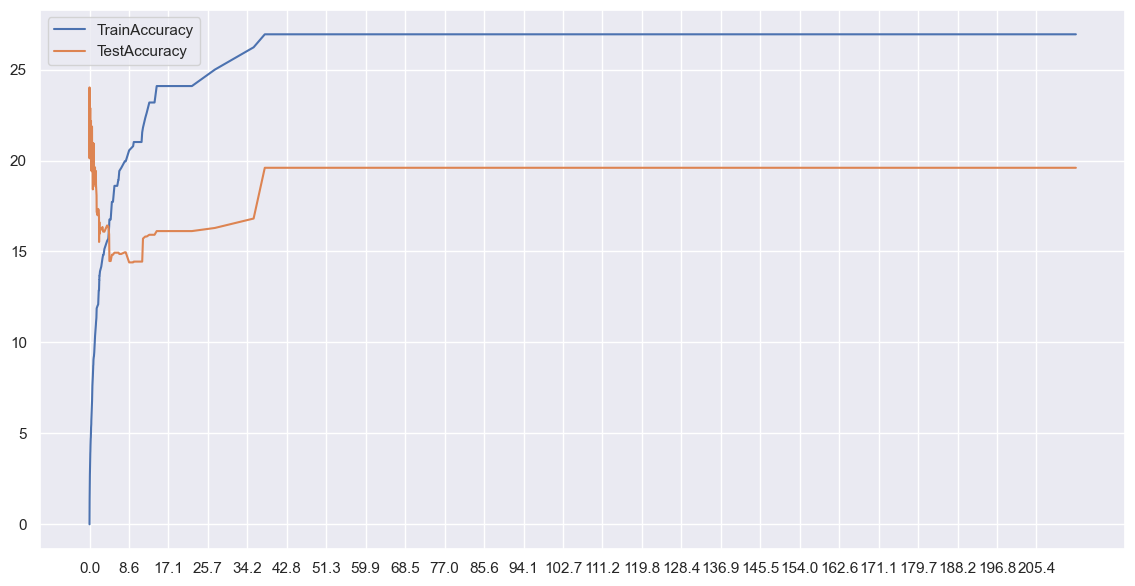

In [31]:
import seaborn as sns
sns.set()
plt.figure(figsize=(14,7))

sns.lineplot(y=accuracy_train,x=alphas,label="TrainAccuracy")

sns.lineplot(y=accuracy_test,x=alphas,label="TestAccuracy")

plt.xticks(ticks=np.arange(0.00,alphas.max(),(alphas.max()-alphas.min())/div
))
plt.show()

Note que le valor de $\alpha$ donde se hace mínimo el error cuadrático medioestá entre  33 y 36, aunque eso hace que el error esobre le conjunto de prueba se vuelva mas grande. Vamos a tomar un valor de 25.6 para alpha y computaremos el árbol basado en ese valor de $\alpha$.

# Juntar Entrenamiento y Validación

In [32]:
print(type(train_feature))
print(type(val_feature))

#######

print(type(train_target))
print(type(val_target))

####
print(train_feature.shape)
print(val_feature.shape)

#####

####
print(train_target.shape)
print(val_target.shape)

###Concatenate Validation and test

train_val_feature=np.concatenate((train_feature,val_feature),axis=0)
train_val_target=np.concatenate((train_target,val_target),axis=0)
print(train_val_feature.shape)
print(train_val_target.shape)



<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(868, 17)
(124, 17)
(868,)
(124,)
(992, 17)
(992,)


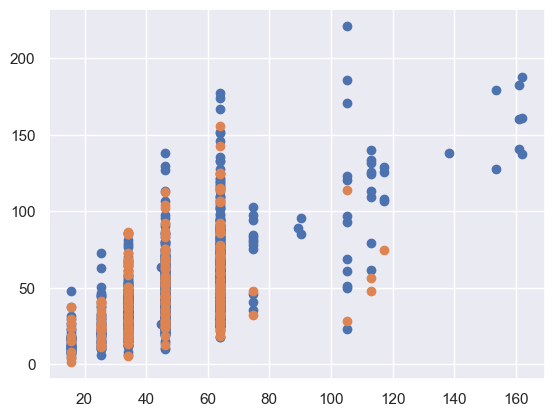

Raíz de la Pérdida cuadrática Entrenamiento: 21.875954183805693
Raíz de la Pérdida cuadrática Prueba: 23.944326413011723


In [33]:
# Plot predicted against actual values but with train + val

from matplotlib import pyplot as plt

# Use the best max_depth 

decision_tree_PM25 = DecisionTreeRegressor(max_depth=4,random_state=123)  # fill in best max depth here
decision_tree_PM25.fit(train_val_feature, train_val_target)

# Predict values for train and test
train_val_prediction = decision_tree_PM25.predict(train_val_feature)
test_prediction = decision_tree_PM25.predict(test_feature)

# Scatter the predictions vs actual values
plt.scatter(train_val_prediction, train_val_target, label='train')  # blue
plt.scatter(test_prediction, test_target, label='test')  # orange
plt.show()
print("Raíz de la Pérdida cuadrática Entrenamiento:",sklearn.metrics.root_mean_squared_error( train_val_prediction, train_val_target))

print("Raíz de la Pérdida cuadrática Prueba:",sklearn.metrics.root_mean_squared_error(test_prediction, test_target))


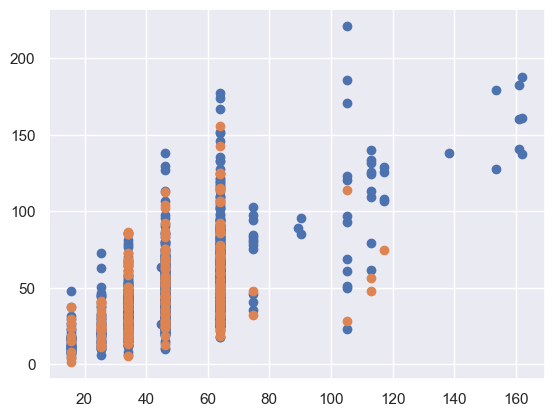

In [34]:
# Plot predicted against actual values

from matplotlib import pyplot as plt

# Use the best max_depth 
decision_tree_PM25_prun_mincost = DecisionTreeRegressor(ccp_alpha=25.6)  # fill in best max depth here
decision_tree_PM25_prun_mincost.fit(train_val_feature, train_val_target)

# Predict values for train and test
train_val_prediction_prun_mincost = decision_tree_PM25.predict(train_val_feature)
test_prediction_prun_mincost = decision_tree_PM25.predict(test_feature)

# Scatter the predictions vs actual values
plt.scatter(train_val_prediction_prun_mincost, train_val_target, label='train')  # blue
plt.scatter(test_prediction_prun_mincost, test_target, label='test')  # orange
plt.show()

In [35]:
from sklearn import tree

listacaract=list(df1_PM25.columns.values)
respuesta=listacaract.pop()
text_representation = tree.export_text(decision_tree_PM25)
print(text_representation)

|--- feature_0 <= 53.50
|   |--- feature_0 <= 34.02
|   |   |--- feature_0 <= 19.85
|   |   |   |--- feature_0 <= 15.02
|   |   |   |   |--- value: [15.69]
|   |   |   |--- feature_0 >  15.02
|   |   |   |   |--- value: [25.40]
|   |   |--- feature_0 >  19.85
|   |   |   |--- feature_4 <= 159.17
|   |   |   |   |--- value: [34.24]
|   |   |   |--- feature_4 >  159.17
|   |   |   |   |--- value: [90.35]
|   |--- feature_0 >  34.02
|   |   |--- feature_13 <= 173.77
|   |   |   |--- feature_5 <= 204.23
|   |   |   |   |--- value: [46.04]
|   |   |   |--- feature_5 >  204.23
|   |   |   |   |--- value: [138.25]
|   |   |--- feature_13 >  173.77
|   |   |   |--- feature_16 <= 66.40
|   |   |   |   |--- value: [44.83]
|   |   |   |--- feature_16 >  66.40
|   |   |   |   |--- value: [153.58]
|--- feature_0 >  53.50
|   |--- feature_16 <= 130.38
|   |   |--- feature_7 <= 176.73
|   |   |   |--- feature_0 <= 138.98
|   |   |   |   |--- value: [64.10]
|   |   |   |--- feature_0 >  138.98
|   |  

[Text(0.5, 0.9, 't-1 <= 53.5\nsquared_error = 901.387\nsamples = 992\nvalue = 48.787'),
 Text(0.25, 0.7, 't-1 <= 34.021\nsquared_error = 422.801\nsamples = 661\nvalue = 38.266'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 't-1 <= 19.854\nsquared_error = 250.946\nsamples = 352\nvalue = 30.573'),
 Text(0.0625, 0.3, 't-1 <= 15.021\nsquared_error = 149.905\nsamples = 105\nvalue = 20.869'),
 Text(0.03125, 0.1, 'squared_error = 66.594\nsamples = 49\nvalue = 15.694'),
 Text(0.09375, 0.1, 'squared_error = 178.863\nsamples = 56\nvalue = 25.397'),
 Text(0.1875, 0.3, 't-5 <= 159.167\nsquared_error = 236.855\nsamples = 247\nvalue = 34.698'),
 Text(0.15625, 0.1, 'squared_error = 213.072\nsamples = 245\nvalue = 34.243'),
 Text(0.21875, 0.1, 'squared_error = 27.344\nsamples = 2\nvalue = 90.354'),
 Text(0.375, 0.5, 't-367 <= 173.771\nsquared_error = 474.337\nsamples = 309\nvalue = 47.03'),
 Text(0.3125, 0.3, 't-6 <= 204.229\nsquared_error = 399.006\nsamples = 305\nvalue = 46.346'),
 Text(0.28125, 

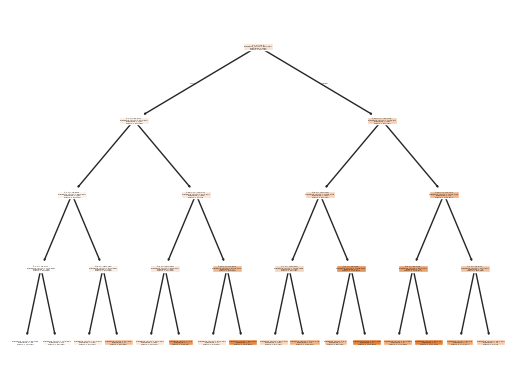

In [36]:
tree.plot_tree(
    decision_tree_PM25,
    feature_names=listacaract,
    filled=True
)

Verficando las dimensiones del conjunto de prueba y del conjunto de entrenamiento para hacer las gráficas de comparación entre los verdaderos valores y sus pronósticos.

In [37]:
print(train_val_prediction.size)
print(train_val_target.size)

print(test_prediction.size)
print(test_target.size)

992
992
249
249


In [38]:
indicetrian_val_test=df1_PM25.index
print(indicetrian_val_test.size)  ###Tamaño del índice
indicetrain_val=indicetrian_val_test[0:993]
indicetest=indicetrian_val_test[993:1241]

1241


In [39]:
print(indicetrain_val.size)
print(indicetest.size)

993
248


In [40]:
targetjoint=np.concatenate((train_val_target,test_target))
predictionjoint=np.concatenate((train_val_prediction,test_prediction))
print(targetjoint.size)
print(predictionjoint.size)

1241
1241


In [41]:
d = {'observado': targetjoint, 'Predicción': predictionjoint}
ObsvsPred=pd.DataFrame(data=d,index=indicetrian_val_test)
ObsvsPred.head(10)

,observado,Predicción
2014-01-06,27.54167,46.043586
2014-01-07,46.20833,34.243367
2014-01-08,38.91667,46.043586
2014-01-09,34.29167,46.043586
2014-01-10,45.58333,46.043586
2014-01-11,45.45833,46.043586
2014-01-12,85.41667,46.043586
2014-01-13,39.41667,64.103077
2014-01-14,24.50000,46.043586
2014-01-15,34.41667,34.243367


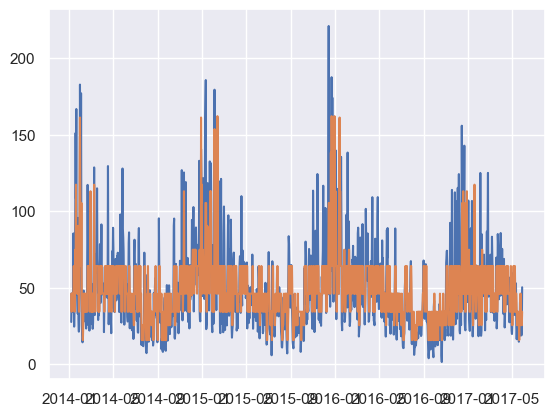

In [42]:
plt.plot(ObsvsPred)


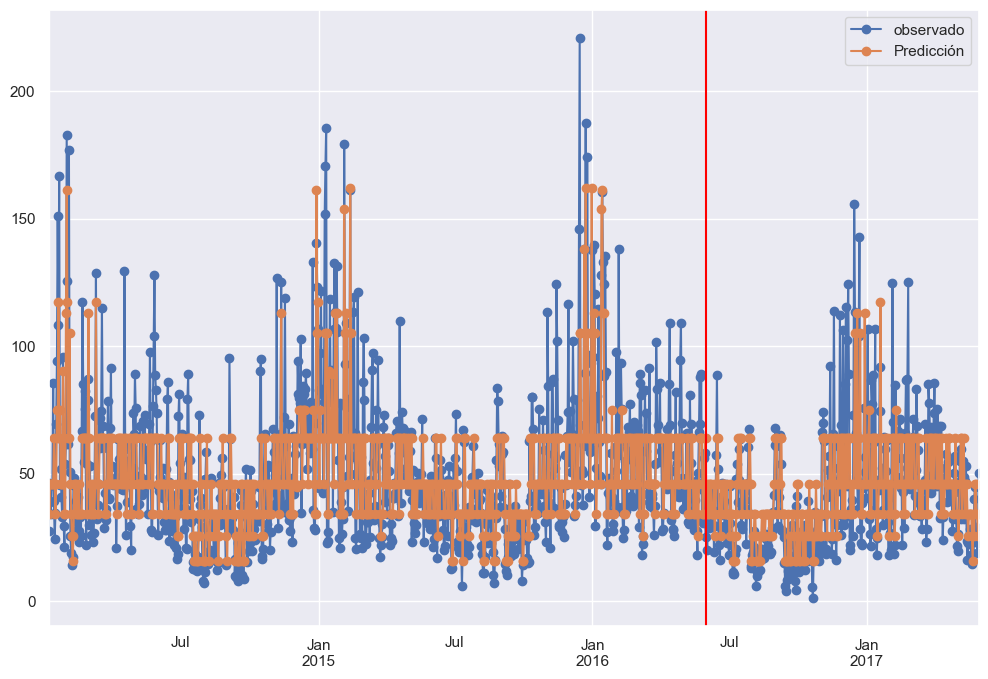

In [43]:
ax = ObsvsPred.plot( marker="o", figsize=(12,8))
ax.axvline(x=indicetrian_val_test[876].date(),color='red')

# Usando el Paquete Forecast

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from skforecast.recursive import ForecasterRecursive
from skforecast.direct import ForecasterDirect

/Users/sergiocalderonunal/opt/anaconda3/envs/NuevoAmbiente/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [78]:
# 1. Carga y Preparación de Datos

Pm25_DF_sk.index = pd.date_range(start='2013-01-01', periods=len(Pm25_DF_sk), freq='D')
print(f"Número de registros: {len(Pm25_DF_sk)}")
Pm25_DF_sk.head()


Número de registros: 1611


,PM25
2013-01-01,78.08333
2013-01-02,58.54167
2013-01-03,45.87500
2013-01-04,49.25000
2013-01-05,52.87500


In [79]:
# 2. División de Datos (70% Train, 10% Val, 20% Test)
n = len(Pm25_DF_sk)
print(n)
n_train = int(n * 0.70)
n_val = int(n * 0.10)
n_test = n - n_train - n_val

datos_train = Pm25_DF_sk.iloc[:n_train]
datos_val   = Pm25_DF_sk.iloc[n_train : n_train + n_val]
datos_test  = Pm25_DF_sk.iloc[n_train + n_val:]

print(f"Registros - Train: {len(datos_train)}, Val: {len(datos_val)}, Test: {len(datos_test)}")

1611
Registros - Train: 1127, Val: 161, Test: 323


In [80]:
# 2. Número de datos Final después de la configuración(70% Train, 10% Val, 20% )
n = len(Pm25_DF_sk)-370
print(n)
n_train = int(n * 0.70)
n_val = int(n * 0.10)
n_test = n - n_train - n_val


print(f"Registros - Train: {n_train}, Val: {n_val}, Test: {n_test}")

1241
Registros - Train: 868, Val: 124, Test: 249


In [81]:
# 3. Configuración del Forecaster
# Definimos los lags específicos solicitados
lags_especificos = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 364,365, 366, 367, 368, 369, 370]

forecaster = ForecasterRecursive(
                estimator = DecisionTreeRegressor(random_state=123), # max_depth=None por defecto
                lags      = lags_especificos
             )

forecaster1 = ForecasterDirect(
                estimator = DecisionTreeRegressor(random_state=123), # max_depth=None por defecto
                lags      = lags_especificos,
                steps=1
             )

In [82]:
X_forecaster, y_forecaster = forecaster.create_train_X_y(Pm25_DF_sk['PM25'])
print(X_forecaster)
print(y_forecaster)
print(len(y_forecaster))
print(type(X_forecaster))
print(type(y_forecaster))

               lag_1     lag_2      lag_3      lag_4      lag_5      lag_6  \
2014-01-06  50.33333  99.75000  129.91670   91.45833  126.70830   96.45833   
2014-01-07  27.54167  50.33333   99.75000  129.91670   91.45833  126.70830   
2014-01-08  46.20833  27.54167   50.33333   99.75000  129.91670   91.45833   
2014-01-09  38.91667  46.20833   27.54167   50.33333   99.75000  129.91670   
2014-01-10  34.29167  38.91667   46.20833   27.54167   50.33333   99.75000   
...              ...       ...        ...        ...        ...        ...   
2017-05-26  44.62500  39.87500   18.33333   23.29167   14.62500   18.20833   
2017-05-27  25.83333  44.62500   39.87500   18.33333   23.29167   14.62500   
2017-05-28  29.12500  25.83333   44.62500   39.87500   18.33333   23.29167   
2017-05-29  18.75000  29.12500   25.83333   44.62500   39.87500   18.33333   
2017-05-30  22.87500  18.75000   29.12500   25.83333   44.62500   39.87500   

                lag_7      lag_8      lag_9     lag_10    lag_3

In [83]:
X_forecaster_train, y_forecaster_train=X_forecaster[0:n_train], y_forecaster[0:n_train]
print(len(y_forecaster_train))

X_forecaster_val, y_forecaster_val=X_forecaster[n_train : n_train + n_val], y_forecaster[n_train : n_train + n_val]
print(len(y_forecaster_val))

X_forecaster_test, y_forecaster_test=X_forecaster[n_train + n_val:], y_forecaster[n_train + n_val:]
print(len(y_forecaster_test))


868
124
249


Configuración de aprendizaje supervisado (X:features/inputs) (Y:targets/resp) para el entrenamiento

In [84]:
print(X_forecaster_train)
print(y_forecaster_train)

               lag_1     lag_2      lag_3      lag_4      lag_5      lag_6  \
2014-01-06  50.33333  99.75000  129.91670   91.45833  126.70830   96.45833   
2014-01-07  27.54167  50.33333   99.75000  129.91670   91.45833  126.70830   
2014-01-08  46.20833  27.54167   50.33333   99.75000  129.91670   91.45833   
2014-01-09  38.91667  46.20833   27.54167   50.33333   99.75000  129.91670   
2014-01-10  34.29167  38.91667   46.20833   27.54167   50.33333   99.75000   
...              ...       ...        ...        ...        ...        ...   
2016-05-18  39.50000  27.79167   43.87500   33.08333   35.37500   69.33333   
2016-05-19  46.95833  39.50000   27.79167   43.87500   33.08333   35.37500   
2016-05-20  27.54167  46.95833   39.50000   27.79167   43.87500   33.08333   
2016-05-21  18.00000  27.54167   46.95833   39.50000   27.79167   43.87500   
2016-05-22  50.25000  18.00000   27.54167   46.95833   39.50000   27.79167   

                lag_7      lag_8      lag_9     lag_10    lag_3

In [85]:
print(train_feature) 
print(train_target)

[[ 50.33333  99.75    129.9167  ...  45.875    58.54167  78.08333]
 [ 27.54167  50.33333  99.75    ...  49.25     45.875    58.54167]
 [ 46.20833  27.54167  50.33333 ...  52.875    49.25     45.875  ]
 ...
 [ 27.54167  46.95833  39.5     ...  49.75     41.79167  46.83333]
 [ 18.       27.54167  46.95833 ...  71.58333  49.75     41.79167]
 [ 50.25     18.       27.54167 ...  43.79167  71.58333  49.75   ]]
[ 27.54167   46.20833   38.91667   34.29167   45.58333   45.45833
  85.41667   39.41667   24.5       34.41667   69.58333   94.08333
 151.0833   108.125    166.7083    45.70833   51.70833   40.75
  32.83333   95.58333   29.45833   21.20833   53.95833   61.54167
 182.6667   125.5417    61.70833  177.        50.75      25.5
  18.91667   14.25      17.45833   45.45833   48.08333   33.04167
  39.375     31.        27.95833   40.875     27.33333   23.25
  33.125     25.58333   66.70833  117.125     85.125     54.58333
  82.375     75.33333   21.91667   53.75      87.04167   78.95833
  29.916

In [86]:
len(df1['t'])

1611

son 868+370 para las ventanas

In [87]:
datos_train_total_values=df1['t'].iloc[0:1238]
print(datos_train_total_values)

2013-01-01    78.08333
2013-01-02    58.54167
2013-01-03    45.87500
2013-01-04    49.25000
2013-01-05    52.87500
                ...   
2016-05-18    46.95833
2016-05-19    27.54167
2016-05-20    18.00000
2016-05-21    50.25000
2016-05-22    66.20833
Freq: D, Name: t, Length: 1238, dtype: float64


In [88]:
# 4. Entrenamiento
# Entrenamos con el set de entrenamiento inicial
forecaster.fit(y=datos_train_total_values)
print(forecaster.estimator.get_depth())
pred_forecaster_test=forecaster.estimator.predict(X_forecaster_test)
print(len(pred_forecaster_test))


27
249


In [93]:
np.allclose(manual_pred_test,pred_forecaster_test)

True

In [57]:
print(manual_pred_test)
print(pred_forecaster_test)

[ 43.75      17.5       14.625      7.833333   7.833333  11.29167
  41.5       41.5        8.        14.625      7.833333  18.
  31.54167   31.54167   13.        43.625     43.625     37.125
  27.375     61.25      76.33333   18.625     42.04167   48.79167
  62.70833   28.04167   27.375     16.125     48.         9.583333
  19.91667   48.08333   48.79167   19.91667   85.41667   22.70833
  19.91667   27.375     26.08333   35.45833   58.45833   37.70833
  77.29167   25.29167   26.625     27.125     19.91667   65.5
  37.79167   42.58333   67.83333   46.58333   49.16667   44.58333
  39.33333   73.20833  103.        23.        20.95833   22.66667
  35.45833   43.375     37.79167   47.25      63.08333   31.625
  20.25      53.       103.        52.79167   39.83333   34.875
 103.        57.95833  109.0833    46.58333   97.20833   36.125
  67.20833   65.5      126.75      39.91667   81.95833   68.91667
  81.375     43.79167  109.2083    78.95833  126.75      62.54167
 220.9583    64.66667   43

# Explicabilidad

In [89]:
from sklearn.inspection import PartialDependenceDisplay
import shap

explainer = shap.TreeExplainer(forecaster.regressor)
shap_values = explainer.shap_values(X_forecaster_train)

/Users/sergiocalderonunal/opt/anaconda3/envs/NuevoAmbiente/lib/python3.10/site-packages/skforecast/base/_forecaster_base.py:357: FutureWarning: The `regressor` attribute is deprecated and will be removed in future versions. Use `estimator` instead.
  warnings.warn(


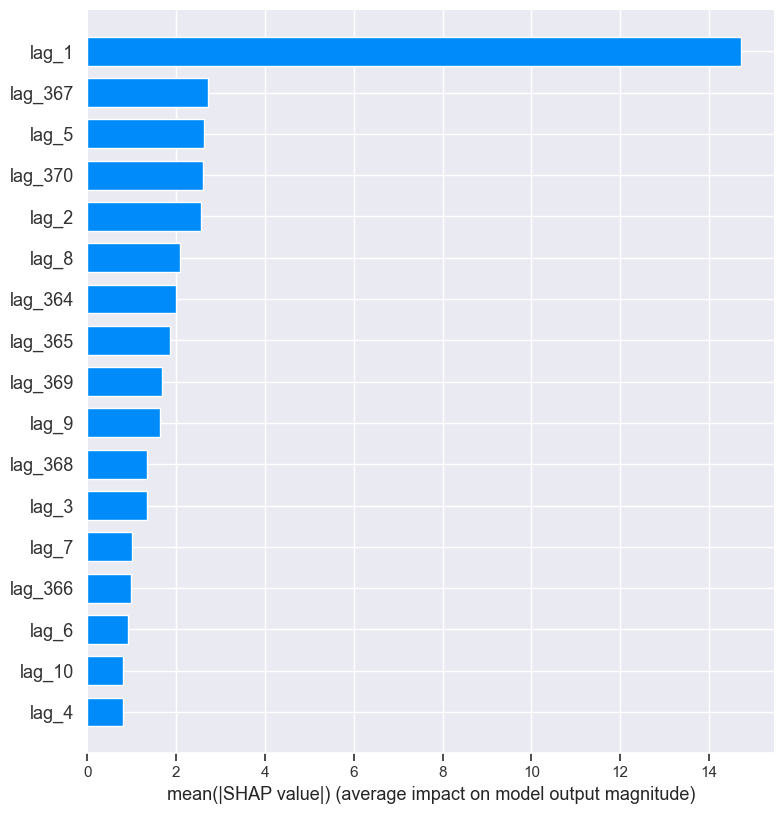

In [90]:
shap.summary_plot(shap_values, X_forecaster_train, plot_type="bar")

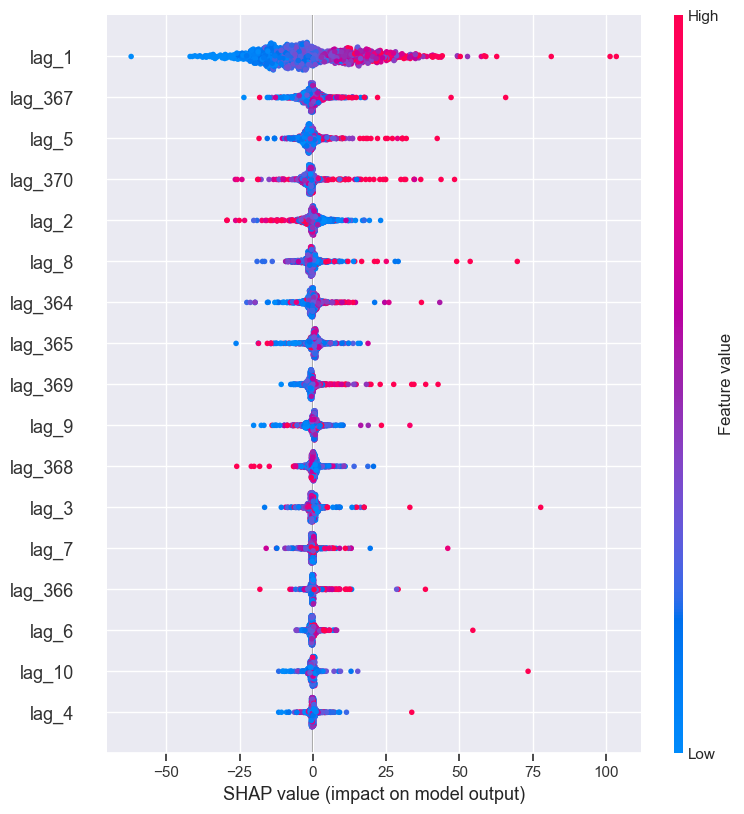

In [92]:
shap.summary_plot(shap_values, X_forecaster_train)

In [94]:
importance = forecaster.get_feature_importances()
importance.head(10)

,feature,importance
0,lag_1,0.331580
16,lag_370,0.071865
13,lag_367,0.066259
7,lag_8,0.064746
10,lag_364,0.057211
8,lag_9,0.050385
4,lag_5,0.045484
1,lag_2,0.043927
2,lag_3,0.042732
11,lag_365,0.033434


In [58]:
len(df1['t'])

1611

In [59]:
df1['t'].iloc[0:1362]

2013-01-01    78.083330
2013-01-02    58.541670
2013-01-03    45.875000
2013-01-04    49.250000
2013-01-05    52.875000
                ...    
2016-09-19    17.541670
2016-09-20     9.583333
2016-09-21    13.291670
2016-09-22    22.583330
2016-09-23    29.750000
Freq: D, Name: t, Length: 1362, dtype: float64

# Backtesting

1362=868+124+370
1362=992+370

In [61]:
from skforecast.model_selection import TimeSeriesFold
from skforecast.model_selection import backtesting_forecaster
cv = TimeSeriesFold(
         steps                 = 1,
         initial_train_size    = 1238,
         refit                 = False,
         fixed_train_size      = False,
         gap                   = 0,
         allow_incomplete_fold = True
     )

metric, predictions_backtest = backtesting_forecaster(
                          forecaster    = forecaster,
                          y             = df1['t'].iloc[0:1611],
                          cv            = cv,
                          metric        = 'mean_squared_error',
                          n_jobs        = 'auto',
                          verbose       = True,
                          show_progress = True
                      )

Information of folds
--------------------
Number of observations used for initial training: 1238
Number of observations used for backtesting: 373
    Number of folds: 373
    Number skipped folds: 0 
    Number of steps per fold: 1
    Number of steps to exclude between last observed data (last window) and predictions (gap): 0

Fold: 0
    Training:   2013-01-01 00:00:00 -- 2016-05-22 00:00:00  (n=1238)
    Validation: 2016-05-23 00:00:00 -- 2016-05-23 00:00:00  (n=1)
Fold: 1
    Training:   No training in this fold
    Validation: 2016-05-24 00:00:00 -- 2016-05-24 00:00:00  (n=1)
Fold: 2
    Training:   No training in this fold
    Validation: 2016-05-25 00:00:00 -- 2016-05-25 00:00:00  (n=1)
Fold: 3
    Training:   No training in this fold
    Validation: 2016-05-26 00:00:00 -- 2016-05-26 00:00:00  (n=1)
Fold: 4
    Training:   No training in this fold
    Validation: 2016-05-27 00:00:00 -- 2016-05-27 00:00:00  (n=1)
Fold: 5
    Training:   No training in this fold
    Validation: 20

100%|██████████| 373/373 [00:04<00:00, 90.48it/s] 


Note que son 373 folds: 124(entrenamiento)+249(prueba)

In [62]:
display(metric)
print(len(predictions_backtest))
predictions_backtest.tail(249)

,mean_squared_error
0,875.119195


373


,fold,pred
2016-09-24,124,43.750000
2016-09-25,125,17.500000
2016-09-26,126,14.625000
2016-09-27,127,7.833333
2016-09-28,128,7.833333
...,...,...
2017-05-26,368,32.125000
2017-05-27,369,18.000000
2017-05-28,370,27.375000
2017-05-29,371,24.041670


In [63]:
manual_pred_test

array([ 43.75    ,  17.5     ,  14.625   ,   7.833333,   7.833333,
        11.29167 ,  41.5     ,  41.5     ,   8.      ,  14.625   ,
         7.833333,  18.      ,  31.54167 ,  31.54167 ,  13.      ,
        43.625   ,  43.625   ,  37.125   ,  27.375   ,  61.25    ,
        76.33333 ,  18.625   ,  42.04167 ,  48.79167 ,  62.70833 ,
        28.04167 ,  27.375   ,  16.125   ,  48.      ,   9.583333,
        19.91667 ,  48.08333 ,  48.79167 ,  19.91667 ,  85.41667 ,
        22.70833 ,  19.91667 ,  27.375   ,  26.08333 ,  35.45833 ,
        58.45833 ,  37.70833 ,  77.29167 ,  25.29167 ,  26.625   ,
        27.125   ,  19.91667 ,  65.5     ,  37.79167 ,  42.58333 ,
        67.83333 ,  46.58333 ,  49.16667 ,  44.58333 ,  39.33333 ,
        73.20833 , 103.      ,  23.      ,  20.95833 ,  22.66667 ,
        35.45833 ,  43.375   ,  37.79167 ,  47.25    ,  63.08333 ,
        31.625   ,  20.25    ,  53.      , 103.      ,  52.79167 ,
        39.83333 ,  34.875   , 103.      ,  57.95833 , 109.083

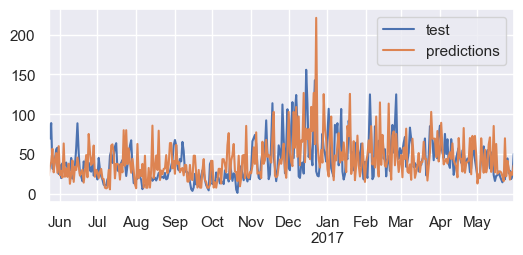

In [64]:
fig, ax = plt.subplots(figsize=(6, 2.5))
df1.loc[predictions_backtest.index, 't'].plot(ax=ax, label='test')
predictions_backtest['pred'].plot(ax=ax, label='predictions')
ax.legend();

In [73]:
importance = forecaster.get_feature_importances()
importance.head(10)

,feature,importance
0,lag_1,0.945415
17,lag_18,0.034518
16,lag_17,0.020067
1,lag_2,0.000000
18,lag_19,0.000000
15,lag_16,0.000000
14,lag_15,0.000000
13,lag_14,0.000000
12,lag_13,0.000000
11,lag_12,0.000000


# Hyperparameters Tuning

1238=868+370(Datos de entrenamiento mas la ventana)
1362=868+370+124(Datos de entrenamiento + validación+ mas la ventana)

In [66]:
from skforecast.model_selection import grid_search_forecaster
forecaster_tuning = ForecasterRecursive(
                estimator = DecisionTreeRegressor(random_state=123), # max_depth=None por defecto
                lags      = 1
             )

cv = TimeSeriesFold(
         steps                 = 1,
         initial_train_size    = 1238,
         refit                 = False,
         fixed_train_size      = False,
         gap                   = 0,
         allow_incomplete_fold = True
     )
# Candidate values for lags

lags_grid = [5,10,15,20,370]

# Candidate values for estimator's hyperparameters
param_grid = {
    'max_depth': [1,2,3,4,5,6,7,8,9,10]
}

results_grid = grid_search_forecaster(
                    forecaster  = forecaster,
                    y           = df1['t'].iloc[0:1362],
                    cv          = cv,
                    param_grid  = param_grid,
                    lags_grid   = lags_grid,
                    metric      = 'mean_squared_error',  
                    return_best = True,
                    n_jobs      = 'auto',
                    verbose     = False
                )

lags grid: 100%|██████████| 5/5 [00:06<00:00,  1.21s/it]    


╭─────────────────────────────── IgnoredArgumentWarning ───────────────────────────────╮
│ The number of bins has been reduced from 10 to 5 due to duplicated edges caused by   │
│ repeated predicted values.                                                           │
│                                                                                      │
│ Category : skforecast.exceptions.IgnoredArgumentWarning                              │
│ Location :                                                                           │
│ /Users/sergiocalderonunal/opt/anaconda3/envs/NuevoAmbiente/lib/python3.10/site-packa │
│ ges/skforecast/preprocessing/preprocessing.py:2515                                   │
│ Suppress : warnings.simplefilter('ignore', category=IgnoredArgumentWarning)          │
╰──────────────────────────────────────────────────────────────────────────────────────╯

In [67]:
results_grid

,lags,lags_label,params,mean_squared_error,max_depth
0,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",{'max_depth': 3},209.914035,3
1,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",{'max_depth': 4},211.106367,4
2,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",{'max_depth': 3},213.195669,3
3,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",{'max_depth': 5},213.375431,5
4,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",{'max_depth': 3},214.433858,3
5,"[1, 2, 3, 4, 5]","[1, 2, 3, 4, 5]",{'max_depth': 3},215.379997,3
6,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",{'max_depth': 7},222.597500,7
7,"[1, 2, 3, 4, 5]","[1, 2, 3, 4, 5]",{'max_depth': 4},223.896540,4
8,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",{'max_depth': 5},231.057045,5
9,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",{'max_depth': 4},232.824355,4


In [68]:
forecaster_tuning

=================== 
ForecasterRecursive 
=================== 
Estimator: DecisionTreeRegressor 
Lags: [1] 
Window features: None 
Window size: 1 
Series name: None 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: None 
Training index type: None 
Training index frequency: None 
Estimator parameters: 
    {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None,
    'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0,
    'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf':
    0.0, 'monotonic_cst': None, 'random_state': 123, 'splitter': 'best'} 
fit_kwargs: {} 
Creation date: 2026-04-14 20:45:25 
Last fit date: None 
Skforecast version: 0.21.0 
Python version: 3.10.20 
Forecaster id: None

In [69]:
forecaster_tuning.fit(y=df1['t'].iloc[0:1362],store_in_sample_residuals=True)
predictions_interval_tuning=forecaster_tuning.predict_interval(steps=14,
                                  interval=[2.5,97.5],
                                  method='bootstrapping',
                                  n_boot=200)
predictions_interval_tuning

,pred,lower_bound,upper_bound
2016-09-24,25.736110,12.728296,39.048610
2016-09-25,24.583330,10.902081,51.218052
2016-09-26,23.145830,7.972396,71.258330
2016-09-27,44.680553,6.812500,97.865629
2016-09-28,68.750000,8.207291,105.951572
2016-09-29,48.791670,7.979687,123.366136
2016-09-30,48.583335,8.125782,140.442186
2016-10-01,36.333330,8.013538,135.788575
2016-10-02,26.166665,10.967014,133.527623
2016-10-03,12.250000,12.726042,132.524480


In [70]:
import matplotlib.ticker as ticker
def plot_predicted_intervals(
    predictions: pd.DataFrame,
    y_true: pd.DataFrame,
    target_variable: str,
    initial_x_zoom: list=None,
    title: str=None,
    xaxis_title: str=None,
    yaxis_title: str=None,
    ax: plt.Axes=None
):
    """
    Plot predicted intervals vs real values

    Parameters
    ----------
    predictions : pandas DataFrame
        Predicted values and intervals.
    y_true : pandas DataFrame
        Real values of target variable.
    target_variable : str
        Name of target variable.
    initial_x_zoom : list, default `None`
        Initial zoom of x-axis, by default None.
    title : str, default `None`
        Title of the plot, by default None.
    xaxis_title : str, default `None`
        Title of x-axis, by default None.
    yaxis_title : str, default `None`
        Title of y-axis, by default None.
    ax : matplotlib axes, default `None`
        Axes where to plot, by default None.
    
    """
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 3))

    y_true.loc[predictions.index, target_variable].plot(ax=ax, label='Real value')
    predictions['pred'].plot(ax=ax, label='prediction')
    ax.fill_between(
        predictions.index,
        predictions['lower_bound'],
        predictions['upper_bound'],
        color = '#444444',
        alpha = 0.3,
    )
    ax.yaxis.set_major_formatter(ticker.EngFormatter())
    ax.set_ylabel(yaxis_title)
    ax.set_xlabel(xaxis_title)
    ax.set_title(title)
    ax.legend()

    if initial_x_zoom is not None:
        ax.set_xlim(initial_x_zoom)

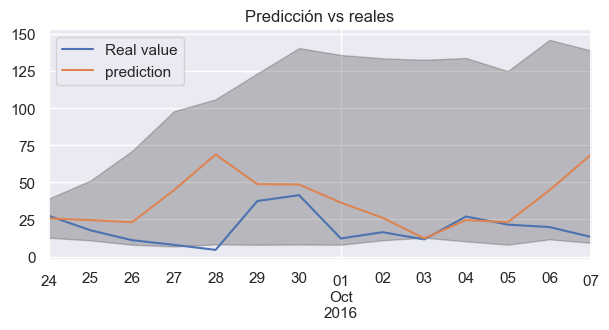

In [71]:

plot_predicted_intervals(
    predictions         = predictions_interval_tuning,
    y_true              = df1.iloc[1362:1378],
    target_variable     = "t",
    title               = "Predicción vs reales"
)
